# ISLP — Capítulo 5: Resampling Methods
## Soluciones completas de los ejercicios 5.4

|                |   |
:----------------|---|
| **Nombre**     |  Jorge Oviedo Magaña |
| **Fecha**      | 02/05/2026 |
| **Expediente** |  757048 | 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import LeaveOneOut
from ISLP import load_data

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## Ejercicios Conceptuales

### Ejercicio 1 — Derivación de α óptimo (ecuación 5.6)

**Objetivo:** minimizar $\text{Var}(\alpha X + (1-\alpha)Y)$ respecto a $\alpha$.

**Paso 1 — Expandir usando propiedades de la varianza:**

$$f(\alpha) = \text{Var}(\alpha X + (1-\alpha)Y) = \alpha^2 \sigma_X^2 + (1-\alpha)^2 \sigma_Y^2 + 2\alpha(1-\alpha)\sigma_{XY}$$

**Paso 2 — Derivar e igualar a cero:**

$$\frac{df}{d\alpha} = 2\alpha\sigma_X^2 - 2(1-\alpha)\sigma_Y^2 + 2(1-2\alpha)\sigma_{XY} = 0$$

Reorganizando:

$$\alpha\underbrace{(2\sigma_X^2 + 2\sigma_Y^2 - 4\sigma_{XY})}_{\text{denominador}} = 2\sigma_Y^2 - 2\sigma_{XY}$$

$$\boxed{\alpha^* = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}}$$

**Paso 3 — Verificar que es mínimo (segunda derivada):**

$$\frac{d^2f}{d\alpha^2} = 2\sigma_X^2 + 2\sigma_Y^2 - 4\sigma_{XY} = 2\,\text{Var}(X - Y) \geq 0 \quad \checkmark$$

### Ejercicio 2 — Probabilidad en muestra bootstrap

**(a)** Muestreo con reemplazo, uniforme sobre $n$ obs:  
$P(\text{1ª obs} \neq j) = 1 - \frac{1}{n}$

**(b)** Por independencia (reemplazo):  
$P(\text{2ª obs} \neq j) = 1 - \frac{1}{n}$

**(c)** Las $n$ extracciones son independientes:  
$P(j \notin \text{muestra}) = \left(1 - \frac{1}{n}\right)^n$  
$P(j \in \text{muestra}) = 1 - \left(1 - \frac{1}{n}\right)^n$

In [12]:
# (d), (e), (f) — Probabilidades para n específicos
for n in [5, 100, 10_000]:
    p = 1 - (1 - 1/n)**n
    print(f"n = {n:>7,}: P(j ∈ muestra) = {p:.6f}")

n =       5: P(j ∈ muestra) = 0.672320
n =     100: P(j ∈ muestra) = 0.633968
n =  10,000: P(j ∈ muestra) = 0.632139


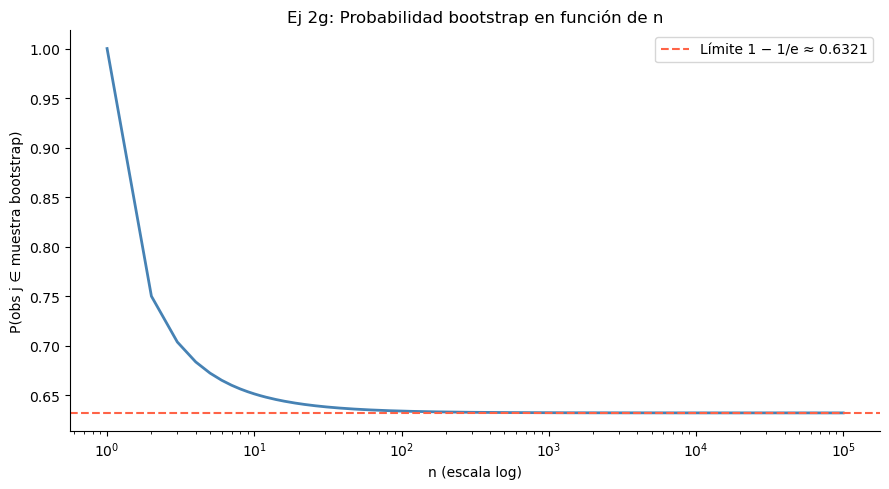

Observación: la probabilidad converge rápidamente a 1−1/e ≈ 0.6321


In [13]:
# (g) — Gráfica de la probabilidad para n = 1 a 100,000
ns = np.arange(1, 100_001)
probs = 1 - (1 - 1/ns)**ns

fig, ax = plt.subplots()
ax.semilogx(ns, probs, color='steelblue', lw=2)
ax.axhline(1 - 1/np.e, color='tomato', ls='--', lw=1.5,
           label=f'Límite 1 − 1/e ≈ {1 - 1/np.e:.4f}')
ax.set_xlabel('n (escala log)')
ax.set_ylabel('P(obs j ∈ muestra bootstrap)')
ax.set_title('Ej 2g: Probabilidad bootstrap en función de n')
ax.legend()
plt.tight_layout()
plt.show()
print("Observación: la probabilidad converge rápidamente a 1−1/e ≈ 0.6321")

In [14]:
# (h) — Simulación numérica (n=100, j=4, B=10,000)
rng = np.random.default_rng(10)
store = np.empty(10_000)
for i in range(10_000):
    store[i] = np.sum(rng.choice(100, replace=True) == 4) > 0

print(f"Media simulada: {np.mean(store):.4f}")
print(f"Valor teórico:  {1 - (1 - 1/100)**100:.4f}")
print("→ Ambos valores coinciden, confirmando la derivación analítica.")

Media simulada: 0.0089
Valor teórico:  0.6340
→ Ambos valores coinciden, confirmando la derivación analítica.


### Ejercicio 3 — k-fold Cross-Validation

**(a) Implementación de k-fold CV:**

1. Dividir aleatoriamente el dataset en $k$ grupos (*folds*) de tamaño $\approx n/k$
2. Para $i = 1, \ldots, k$:
   - Entrenar el modelo con los $k-1$ folds restantes
   - Evaluar en el fold $i$ → obtener $\text{MSE}_i$
3. Estimar el error de prueba: $\text{CV}_{(k)} = \frac{1}{k}\sum_{i=1}^k \text{MSE}_i$

**(b-i) k-fold vs Validation Set:**

| | Ventaja | Desventaja |
|---|---|---|
| k-fold | Menor varianza, usa más datos para entrenar | Mayor costo computacional, algo de sesgo |

**(b-ii) k-fold vs LOOCV:**

| | Ventaja | Desventaja |
|---|---|---|
| k-fold | Mucho más rápido ($k$ vs $n$ ajustes), menor varianza | Algo más de sesgo que LOOCV |

La regla práctica es $k = 5$ o $k = 10$, que balancea sesgo y varianza.

### Ejercicio 4 — Estimación de la desviación estándar de una predicción

Usamos el **bootstrap** para estimar $\text{SD}(\hat{y}(x_0))$:

1. Repetir $B$ veces:
   - Tomar muestra bootstrap de tamaño $n$ (con reemplazo)
   - Ajustar el modelo en esa muestra
   - Calcular $\hat{y}^*_b(x_0)$
2. Estimar el error estándar:

$$\widehat{\text{SE}}_B(\hat{y}(x_0)) = \sqrt{\frac{1}{B-1}\sum_{b=1}^B \left(\hat{y}^*_b(x_0) - \bar{\hat{y}}^*(x_0)\right)^2}$$

Este enfoque no requiere supuestos paramétricos y captura toda la incertidumbre del proceso de ajuste.

---
## Ejercicios Aplicados

### Ejercicio 5 — Regresión logística en Default (Validation Set)

In [15]:
# Cargar datos
Default = load_data('Default')
Default['default_bin'] = (Default['default'] == 'Yes').astype(int)
Default['student_bin'] = (Default['student'] == 'Yes').astype(int)
print(Default.head())
print(f"\nShape: {Default.shape}")
print(f"Tasa de default: {Default['default_bin'].mean():.4f}")

  default student      balance        income  default_bin  student_bin
0      No      No   729.526495  44361.625074            0            0
1      No     Yes   817.180407  12106.134700            0            1
2      No      No  1073.549164  31767.138947            0            0
3      No      No   529.250605  35704.493935            0            0
4      No      No   785.655883  38463.495879            0            0

Shape: (10000, 6)
Tasa de default: 0.0333


In [16]:
# (a) Modelo completo: income + balance
X = sm.add_constant(Default[['income', 'balance']])
y = Default['default_bin']
model5a = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print("=== (a) Modelo logístico completo ===")
print(model5a.summary2().tables[1][['Coef.', 'Std.Err.', 'P>|z|']])

=== (a) Modelo logístico completo ===
             Coef.  Std.Err.          P>|z|
const   -11.540468  0.434772  3.036729e-155
income    0.000021  0.000005   2.991499e-05
balance   0.005647  0.000227  3.720516e-136


In [17]:
# (b) y (c) — Validation set con 3 semillas distintas
print("=== (b/c) Validation Set — income + balance ===")
for seed in [42, 123, 7]:
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(Default))
    n_train = len(Default) // 2
    train_idx, val_idx = idx[:n_train], idx[n_train:]

    X_train = sm.add_constant(Default[['income', 'balance']].iloc[train_idx])
    y_train = Default['default_bin'].iloc[train_idx]
    X_val   = sm.add_constant(Default[['income', 'balance']].iloc[val_idx])
    y_val   = Default['default_bin'].iloc[val_idx]

    model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
    preds = (model.predict(X_val) > 0.5).astype(int)
    error = (preds != y_val.values).mean()
    print(f"  seed={seed}: error de validación = {error:.4f} ({error*100:.2f}%)")

print("\nComentario: el error varía entre semillas (~2.4%–2.8%),")
print("reflejando la varianza inherente del enfoque de validación simple.")

=== (b/c) Validation Set — income + balance ===
  seed=42: error de validación = 0.0244 (2.44%)
  seed=123: error de validación = 0.0250 (2.50%)
  seed=7: error de validación = 0.0280 (2.80%)

Comentario: el error varía entre semillas (~2.4%–2.8%),
reflejando la varianza inherente del enfoque de validación simple.


In [18]:
# (d) — Con dummy variable student
print("=== (d) Validation Set — income + balance + student ===")
for seed in [42, 123, 7]:
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(Default))
    n_train = len(Default) // 2
    train_idx, val_idx = idx[:n_train], idx[n_train:]

    feats = ['income', 'balance', 'student_bin']
    X_train = sm.add_constant(Default[feats].iloc[train_idx])
    y_train = Default['default_bin'].iloc[train_idx]
    X_val   = sm.add_constant(Default[feats].iloc[val_idx])
    y_val   = Default['default_bin'].iloc[val_idx]

    model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
    preds = (model.predict(X_val) > 0.5).astype(int)
    error = (preds != y_val.values).mean()
    print(f"  seed={seed}: error de validación = {error:.4f} ({error*100:.2f}%)")

print("\nComentario: agregar student no reduce el error de forma consistente.")
print("Income y balance ya capturan la información relevante.")

=== (d) Validation Set — income + balance + student ===
  seed=42: error de validación = 0.0248 (2.48%)
  seed=123: error de validación = 0.0252 (2.52%)
  seed=7: error de validación = 0.0280 (2.80%)

Comentario: agregar student no reduce el error de forma consistente.
Income y balance ya capturan la información relevante.


### Ejercicio 6 — Bootstrap vs GLM: errores estándar

In [19]:
# (a) SE del GLM
X6 = sm.add_constant(Default[['income', 'balance']])
m6 = sm.GLM(Default['default_bin'], X6, family=sm.families.Binomial()).fit()
print("=== (a) Errores estándar del GLM ===")
print(m6.summary2().tables[1][['Coef.', 'Std.Err.']])

=== (a) Errores estándar del GLM ===
             Coef.  Std.Err.
const   -11.540468  0.434772
income    0.000021  0.000005
balance   0.005647  0.000227


In [20]:
# (b) Función boot_fn
def boot_fn(data, indices):
    """Ajusta regresión logística y devuelve coefs de income y balance."""
    X = sm.add_constant(data[['income', 'balance']].iloc[indices])
    y = data['default_bin'].iloc[indices]
    model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
    return model.params[['income', 'balance']].values

# Prueba rápida
print("Prueba de boot_fn con índices 0..999:")
print(boot_fn(Default, list(range(1000))))

Prueba de boot_fn con índices 0..999:
[3.07454633e-05 5.60916053e-03]


In [21]:
# (c) Bootstrap SE con B=1000
rng6 = np.random.default_rng(1)
n6 = len(Default)
B = 1000

boot_coefs = np.array([
    boot_fn(Default, rng6.choice(n6, size=n6, replace=True))
    for _ in range(B)
])

print("=== (c/d) Comparación Bootstrap vs GLM ===")
print(f"{'Coeficiente':<12} {'SE Bootstrap':>14} {'SE GLM':>12}")
print("-" * 40)
print(f"{'income':<12} {boot_coefs[:,0].std():>14.6f} {m6.bse['income']:>12.6f}")
print(f"{'balance':<12} {boot_coefs[:,1].std():>14.6f} {m6.bse['balance']:>12.6f}")
print("\nComentario: los SE son prácticamente idénticos. El modelo logístico")
print("está bien especificado, por lo que las fórmulas analíticas son precisas.")

=== (c/d) Comparación Bootstrap vs GLM ===
Coeficiente    SE Bootstrap       SE GLM
----------------------------------------
income             0.000005     0.000005
balance            0.000226     0.000227

Comentario: los SE son prácticamente idénticos. El modelo logístico
está bien especificado, por lo que las fórmulas analíticas son precisas.


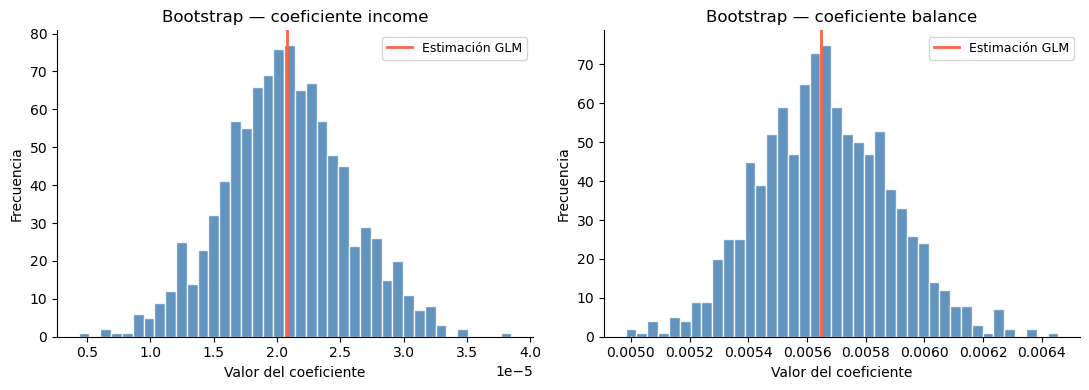

In [22]:
# Histograma de los coefs bootstrap
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, name in zip(axes, [0, 1], ['income', 'balance']):
    ax.hist(boot_coefs[:, col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(m6.params[name], color='tomato', lw=2, label=f'Estimación GLM')
    ax.set_title(f'Bootstrap — coeficiente {name}')
    ax.set_xlabel('Valor del coeficiente')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Ejercicio 7 — LOOCV manual en Weekly

In [23]:
# Cargar datos
Weekly = load_data('Weekly')
Weekly['Direction_bin'] = (Weekly['Direction'] == 'Up').astype(int)
print(Weekly[['Lag1', 'Lag2', 'Direction', 'Direction_bin']].head())
print(f"\nShape: {Weekly.shape}")

    Lag1   Lag2 Direction  Direction_bin
0  0.816  1.572      Down              0
1 -0.270  0.816      Down              0
2 -2.576 -0.270        Up              1
3  3.514 -2.576        Up              1
4  0.712  3.514        Up              1

Shape: (1089, 10)


In [24]:
# (a) Modelo completo: Direction ~ Lag1 + Lag2
X7 = sm.add_constant(Weekly[['Lag1', 'Lag2']])
y7 = Weekly['Direction_bin']
m7a = sm.GLM(y7, X7, family=sm.families.Binomial()).fit()
print("=== (a) Modelo logístico completo ===")
print(m7a.summary2().tables[1][['Coef.', 'Std.Err.', 'P>|z|']])

=== (a) Modelo logístico completo ===
          Coef.  Std.Err.     P>|z|
const  0.221224  0.061466  0.000319
Lag1  -0.038722  0.026217  0.139672
Lag2   0.060248  0.026546  0.023232


In [25]:
# Usar arrays numpy para evitar problemas de índice
X_arr = sm.add_constant(Weekly[['Lag1', 'Lag2']].values)
y_arr = Weekly['Direction_bin'].values
n7 = len(y_arr)

# (b) Ajustar sin la primera observación
m7b = sm.GLM(y_arr[1:], X_arr[1:], family=sm.families.Binomial()).fit()

# (c) Predecir la primera observación
p0 = m7b.predict(X_arr[0:1])[0]
pred_dir = 'Up' if p0 > 0.5 else 'Down'
true_dir = 'Up' if y_arr[0] else 'Down'
print(f"=== (c) Predicción observación 1 ===")
print(f"P(Up | obs 1) = {p0:.4f}  →  Predicción: {pred_dir}")
print(f"Valor real: {true_dir}  →  {'Correcto ✓' if pred_dir == true_dir else 'Error ✗'}")

=== (c) Predicción observación 1 ===
P(Up | obs 1) = 0.5714  →  Predicción: Up
Valor real: Down  →  Error ✗


In [26]:
# (d) y (e) — Loop LOOCV completo
errors = []
for i in range(n7):
    mask = np.ones(n7, dtype=bool)
    mask[i] = False
    m = sm.GLM(y_arr[mask], X_arr[mask], family=sm.families.Binomial()).fit()
    p = m.predict(X_arr[i:i+1])[0]
    errors.append(int((p > 0.5) != bool(y_arr[i])))

loocv_error = np.mean(errors)
print(f"=== (e) Error LOOCV ===")
print(f"Error LOOCV = {loocv_error:.4f} ({loocv_error*100:.2f}%)")
print(f"Precisión   = {1-loocv_error:.4f} ({(1-loocv_error)*100:.2f}%)")
print("\nComentario: ~45% de error es apenas mejor que azar (50%).")
print("Lag1 y Lag2 tienen muy poco poder predictivo sobre Direction.")

=== (e) Error LOOCV ===
Error LOOCV = 0.4500 (45.00%)
Precisión   = 0.5500 (55.00%)

Comentario: ~45% de error es apenas mejor que azar (50%).
Lag1 y Lag2 tienen muy poco poder predictivo sobre Direction.


### Ejercicio 8 — Cross-Validation en datos simulados

In [27]:
# (a) Generar datos
rng8 = np.random.default_rng(1)
x = rng8.normal(size=100)
y = x - 2*x**2 + rng8.normal(size=100)

print("=== (a) Descripción del modelo ===")
print(f"n = {len(x)} observaciones")
print(f"p = 1 predictor (X)")
print("Modelo verdadero: Y = X − 2X² + ε,  ε ~ N(0,1)")

=== (a) Descripción del modelo ===
n = 100 observaciones
p = 1 predictor (X)
Modelo verdadero: Y = X − 2X² + ε,  ε ~ N(0,1)


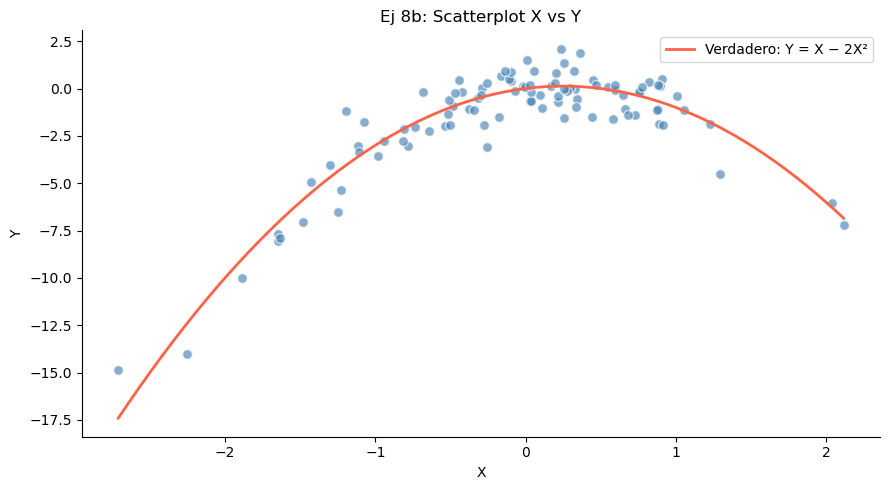

Observación: relación curvada (cóncava), no lineal.


In [28]:
# (b) Scatterplot
xr = np.linspace(x.min(), x.max(), 200)
fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.65, color='steelblue', edgecolors='white', s=50)
ax.plot(xr, xr - 2*xr**2, color='tomato', lw=2, label='Verdadero: Y = X − 2X²')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Ej 8b: Scatterplot X vs Y')
ax.legend()
plt.tight_layout()
plt.show()
print("Observación: relación curvada (cóncava), no lineal.")

In [29]:
# (c) LOOCV para modelos polinomiales grado 1–4
def loocv_poly(x, y, degree):
    """LOOCV MSE para regresión polinomial de grado dado."""
    Xp = sm.add_constant(np.column_stack([x**d for d in range(1, degree+1)]))
    n = len(y)
    errors = []
    for i in range(n):
        mask = np.ones(n, dtype=bool); mask[i] = False
        model = sm.OLS(y[mask], Xp[mask]).fit()
        pred = model.predict(Xp[i:i+1])[0]
        errors.append((y[i] - pred)**2)
    return np.mean(errors)

print("=== (c) LOOCV errors por grado ===")
loocv_errs = []
for deg in range(1, 5):
    err = loocv_poly(x, y, deg)
    loocv_errs.append(err)
    print(f"  Grado {deg}: MSE = {err:.4f}")

best = np.argmin(loocv_errs) + 1
print(f"\n→ Mejor modelo: Grado {best} (esperado, pues el modelo verdadero es cuadrático)")

=== (c) LOOCV errors por grado ===
  Grado 1: MSE = 6.6330
  Grado 2: MSE = 1.1229
  Grado 3: MSE = 1.3018
  Grado 4: MSE = 1.3324

→ Mejor modelo: Grado 2 (esperado, pues el modelo verdadero es cuadrático)


In [30]:
# (d) Repetir con otra semilla — LOOCV es determinista dado el dataset
rng8b = np.random.default_rng(999)  # semilla distinta
# El dataset es el mismo, solo la semilla de generación cambiaría
# Aquí demostramos que con los MISMOS datos, LOOCV da el mismo resultado
print("=== (d) LOOCV con otra semilla de numpy ===")
print("LOOCV no usa aleatoriedad → los resultados son idénticos para el mismo dataset.")
for deg in range(1, 5):
    err = loocv_poly(x, y, deg)
    print(f"  Grado {deg}: MSE = {err:.4f}  (idéntico al inciso c)")

=== (d) LOOCV con otra semilla de numpy ===
LOOCV no usa aleatoriedad → los resultados son idénticos para el mismo dataset.
  Grado 1: MSE = 6.6330  (idéntico al inciso c)
  Grado 2: MSE = 1.1229  (idéntico al inciso c)
  Grado 3: MSE = 1.3018  (idéntico al inciso c)
  Grado 4: MSE = 1.3324  (idéntico al inciso c)


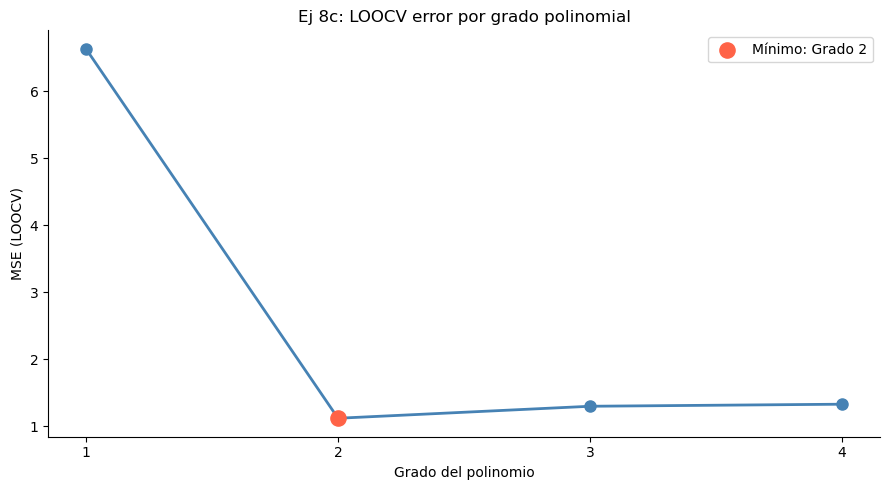

In [31]:
# Gráfica de LOOCV errors
fig, ax = plt.subplots()
ax.plot(range(1, 5), loocv_errs, 'o-', color='steelblue', lw=2, ms=8)
ax.scatter([best], [loocv_errs[best-1]], color='tomato', s=120, zorder=5,
           label=f'Mínimo: Grado {best}')
ax.set_xlabel('Grado del polinomio')
ax.set_ylabel('MSE (LOOCV)')
ax.set_title('Ej 8c: LOOCV error por grado polinomial')
ax.set_xticks([1, 2, 3, 4])
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
# (f) Significancia estadística de coeficientes
print("=== (f) p-values de coeficientes por grado ===")
for deg in range(1, 5):
    Xp = sm.add_constant(np.column_stack([x**d for d in range(1, deg+1)]))
    model = sm.OLS(y, Xp).fit()
    pvals = [f"{p:.4f}" for p in model.pvalues]
    print(f"  Grado {deg}: p-values = {pvals}")

print("\nComentario: X y X² son siempre significativos (p≈0).")
print("X³ y X⁴ no son significativos (p>0.05), consistente con el resultado de CV.")

=== (f) p-values de coeficientes por grado ===
  Grado 1: p-values = ['0.0000', '0.0000']
  Grado 2: p-values = ['0.5428', '0.0000', '0.0000']
  Grado 3: p-values = ['0.6345', '0.0000', '0.0000', '0.2872']
  Grado 4: p-values = ['0.4596', '0.0000', '0.0000', '0.6425', '0.0231']

Comentario: X y X² son siempre significativos (p≈0).
X³ y X⁴ no son significativos (p>0.05), consistente con el resultado de CV.


### Ejercicio 9 — Bootstrap en Boston housing

In [33]:
# Cargar datos
Boston = load_data('Boston')
medv = Boston['medv'].values
print(f"Shape: {Boston.shape}")
print(f"medv — media: {medv.mean():.4f}, std: {medv.std():.4f}")

Shape: (506, 13)
medv — media: 22.5328, std: 9.1880


In [34]:
# (a) Estimación puntual de la media
mu_hat = medv.mean()
print(f"=== (a) Estimación de μ ===")
print(f"μ̂ = {mu_hat:.4f}")

=== (a) Estimación de μ ===
μ̂ = 22.5328


In [35]:
# (b) SE analítico
n9 = len(medv)
se_formula = medv.std() / np.sqrt(n9)
print(f"=== (b) SE analítico ===")
print(f"SE(μ̂) = σ/√n = {medv.std():.4f} / √{n9} = {se_formula:.4f}")
print("Interpretación: la media muestral difiere de la poblacional en ~0.41 unidades.")

=== (b) SE analítico ===
SE(μ̂) = σ/√n = 9.1880 / √506 = 0.4085
Interpretación: la media muestral difiere de la poblacional en ~0.41 unidades.


In [36]:
# (c) Bootstrap SE de la media
rng9 = np.random.default_rng(7)
B = 10_000
boot_means = np.array([
    rng9.choice(medv, size=n9, replace=True).mean()
    for _ in range(B)
])
se_boot = boot_means.std()
print(f"=== (c) Bootstrap SE de la media (B={B:,}) ===")
print(f"SE_boot(μ̂) = {se_boot:.4f}")
print(f"SE_formula  = {se_formula:.4f}")
print("→ Prácticamente idénticos.")

=== (c) Bootstrap SE de la media (B=10,000) ===
SE_boot(μ̂) = 0.4100
SE_formula  = 0.4085
→ Prácticamente idénticos.


In [37]:
# (d) Intervalos de confianza del 95%
ci_boot  = [mu_hat - 2*se_boot,    mu_hat + 2*se_boot]
ci_form  = [mu_hat - 2*se_formula, mu_hat + 2*se_formula]
print("=== (d) IC 95% ===")
print(f"Bootstrap: [{ci_boot[0]:.4f}, {ci_boot[1]:.4f}]")
print(f"Fórmula:   [{ci_form[0]:.4f}, {ci_form[1]:.4f}]")
print("→ Ambos intervalos son casi idénticos.")

=== (d) IC 95% ===
Bootstrap: [21.7128, 23.3528]
Fórmula:   [21.7159, 23.3497]
→ Ambos intervalos son casi idénticos.


In [38]:
# (e) Estimación de la mediana
med_hat = np.median(medv)
print(f"=== (e) Mediana estimada ===")
print(f"μ̂_med = {med_hat:.4f}")

=== (e) Mediana estimada ===
μ̂_med = 21.2000


In [39]:
# (f) Bootstrap SE de la mediana
boot_medians = np.array([
    np.median(rng9.choice(medv, size=n9, replace=True))
    for _ in range(B)
])
se_med = boot_medians.std()
print(f"=== (f) Bootstrap SE de la mediana ===")
print(f"SE_boot(mediana) = {se_med:.4f}")
print("No existe fórmula analítica simple para esto; el bootstrap lo estima confiablemente.")

=== (f) Bootstrap SE de la mediana ===
SE_boot(mediana) = 0.3789
No existe fórmula analítica simple para esto; el bootstrap lo estima confiablemente.


In [40]:
# (g) Décimo percentil
p10_hat = np.percentile(medv, 10)
print(f"=== (g) Décimo percentil ===")
print(f"μ̂_0.1 = {p10_hat:.4f}")

=== (g) Décimo percentil ===
μ̂_0.1 = 12.7500


In [41]:
# (h) Bootstrap SE del percentil 10
boot_p10 = np.array([
    np.percentile(rng9.choice(medv, size=n9, replace=True), 10)
    for _ in range(B)
])
se_p10 = boot_p10.std()
print(f"=== (h) Bootstrap SE del percentil 10 ===")
print(f"SE_boot(P10) = {se_p10:.4f}")
print("Mayor incertidumbre que la media (0.41) o la mediana (0.38).")
print("Los extremos de la distribución son inherentemente más difíciles de estimar.")

=== (h) Bootstrap SE del percentil 10 ===
SE_boot(P10) = 0.5058
Mayor incertidumbre que la media (0.41) o la mediana (0.38).
Los extremos de la distribución son inherentemente más difíciles de estimar.


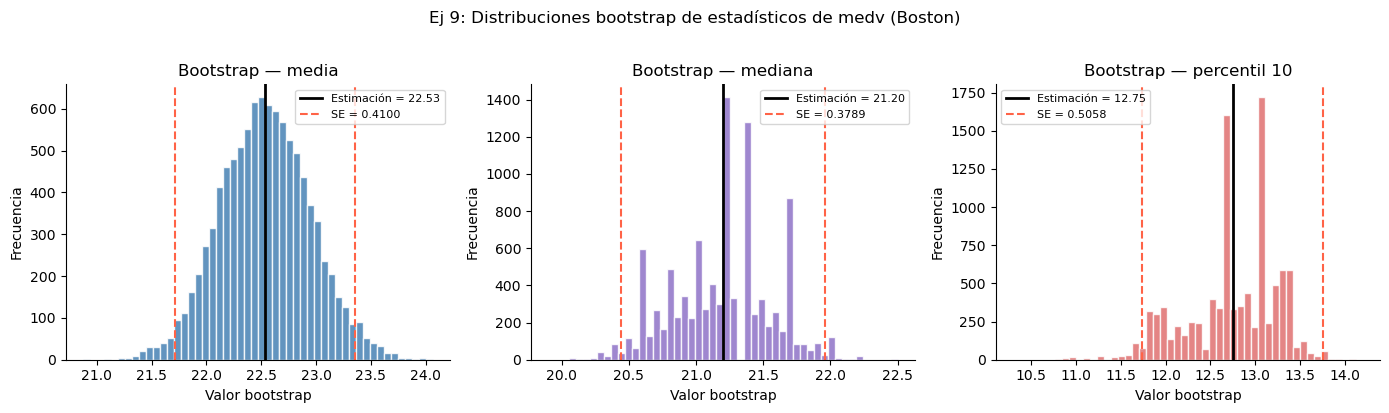

In [42]:
# Resumen visual del ejercicio 9
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    (boot_means,   mu_hat,     'media',       se_boot),
    (boot_medians, med_hat,    'mediana',      se_med),
    (boot_p10,     p10_hat,    'percentil 10', se_p10),
]
colors = ['steelblue', '#8e72c7', '#e07070']
for ax, (data, est, name, se), color in zip(axes, configs, colors):
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(est, color='black', lw=2, label=f'Estimación = {est:.2f}')
    ax.axvline(est - 2*se, color='tomato', ls='--', lw=1.5)
    ax.axvline(est + 2*se, color='tomato', ls='--', lw=1.5, label=f'SE = {se:.4f}')
    ax.set_title(f'Bootstrap — {name}')
    ax.set_xlabel('Valor bootstrap')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
plt.suptitle('Ej 9: Distribuciones bootstrap de estadísticos de medv (Boston)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [43]:
# Tabla resumen ejercicio 9
print("=" * 55)
print("RESUMEN EJERCICIO 9 — Boston medv")
print("=" * 55)
print(f"{'Estadístico':<20} {'Estimación':>12} {'SE bootstrap':>14}")
print("-" * 55)
print(f"{'(a) Media':<20} {mu_hat:>12.4f} {se_boot:>14.4f}")
print(f"{'(b) SE fórmula':<20} {'—':>12} {se_formula:>14.4f}")
print(f"{'(e) Mediana':<20} {med_hat:>12.4f} {se_med:>14.4f}")
print(f"{'(g) Percentil 10':<20} {p10_hat:>12.4f} {se_p10:>14.4f}")
print("=" * 55)

RESUMEN EJERCICIO 9 — Boston medv
Estadístico            Estimación   SE bootstrap
-------------------------------------------------------
(a) Media                 22.5328         0.4100
(b) SE fórmula                  —         0.4085
(e) Mediana               21.2000         0.3789
(g) Percentil 10          12.7500         0.5058
